# Two-Row Temporal QRC Experiment

Tests whether providing two chronologically consecutive events as input improves TTNS prediction.

**Approach A** — Concatenated encoding: 12 qubits (2×6 features), 4096 probability states  
**Approach B** — Sequential encoding: 6 qubits, encode t-1 → reservoir → encode t → reservoir → measure  
**Baseline** — Standard single-row QRC: 6 qubits, 64 states

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from qiskit.circuit import QuantumCircuit
from qiskit_aer import AerSimulator

optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
QRC_CONFIG = {
    "num_layers": 1,
    "shots": 1024,
    "n_iterations": 10,
    "top_k": 1,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "RandomForest"

FEATURE_COLS = ["tide_deriv", "form_fac", "time_since", "slip_size", "high_t_evt", "tide_height"]

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)

QRC Config: {'num_layers': 1, 'shots': 1024, 'n_iterations': 10, 'top_k': 1, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: RandomForest


## Data Loading & Paired Preprocessing

Replicate the filtering/feature logic from `Preprocess.py` inline, but pair consecutive rows **before** the random train/test split.

In [3]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")

# --- Replicate Preprocess.py filtering logic ---
filter_mask = filtered_time["time_to_next_ev_hr"] != -1
TTNS = filtered_time[filter_mask.shift(1) & filter_mask & filter_mask.shift(-1)][1:-1]
known_next_slips = data_orig[filter_mask.shift(1) & filter_mask & filter_mask.shift(-1)][1:-1]

known_next_slips = known_next_slips.copy()
known_next_slips["time_since"] *= 60

X_all = known_next_slips[FEATURE_COLS].values
y_all = (TTNS["time_to_next_ev_hr"] * 3600).values

print(f"Total samples (single-row): {len(X_all)}")
print(f"Features: {FEATURE_COLS}")

Total samples (single-row): 4897
Features: ['tide_deriv', 'form_fac', 'time_since', 'slip_size', 'high_t_evt', 'tide_height']


In [4]:
# Pair consecutive rows BEFORE splitting.
# For index i, pair (X[i], X[i+1]) with target y[i+1].
# This loses the first sample (no predecessor for row 0).

X_prev = X_all[:-1]   # rows 0..n-2  (the t-1 row)
X_curr = X_all[1:]    # rows 1..n-1  (the t row)
y_paired = y_all[1:]  # target is the current row's TTNS

# Concatenated pairs for Approach A (12 features)
X_concat = np.hstack([X_prev, X_curr])

print(f"Paired samples: {len(y_paired)} (lost 1 from {len(y_all)})")
print(f"X_prev shape: {X_prev.shape}, X_curr shape: {X_curr.shape}")
print(f"X_concat shape: {X_concat.shape}")

Paired samples: 4896 (lost 1 from 4897)
X_prev shape: (4896, 6), X_curr shape: (4896, 6)
X_concat shape: (4896, 12)


In [5]:
# Split paired data: 60/20/20 with same random_state as baseline
indices = np.arange(len(y_paired))

idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=1)
idx_train, idx_val = train_test_split(idx_train, test_size=0.25, random_state=1)

# Apply splits to both representations
# Paired prev/curr (for Approach B)
X_prev_train, X_prev_val, X_prev_test = X_prev[idx_train], X_prev[idx_val], X_prev[idx_test]
X_curr_train, X_curr_val, X_curr_test = X_curr[idx_train], X_curr[idx_val], X_curr[idx_test]

# Concatenated (for Approach A)
X_concat_train, X_concat_val, X_concat_test = X_concat[idx_train], X_concat[idx_val], X_concat[idx_test]

# Targets (shared)
y_p_train, y_p_val, y_p_test = y_paired[idx_train], y_paired[idx_val], y_paired[idx_test]

# StandardScaler on concatenated features (fit on train only)
scaler_concat = StandardScaler()
X_concat_train_sc = scaler_concat.fit_transform(X_concat_train)
X_concat_val_sc = scaler_concat.transform(X_concat_val)
X_concat_test_sc = scaler_concat.transform(X_concat_test)

# StandardScaler on prev and curr separately (for Approach B)
scaler_prev = StandardScaler()
X_prev_train_sc = scaler_prev.fit_transform(X_prev_train)
X_prev_val_sc = scaler_prev.transform(X_prev_val)
X_prev_test_sc = scaler_prev.transform(X_prev_test)

scaler_curr = StandardScaler()
X_curr_train_sc = scaler_curr.fit_transform(X_curr_train)
X_curr_val_sc = scaler_curr.transform(X_curr_val)
X_curr_test_sc = scaler_curr.transform(X_curr_test)

print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")
print(f"Concat train shape: {X_concat_train_sc.shape}")
print(f"Prev/Curr train shapes: {X_prev_train_sc.shape}, {X_curr_train_sc.shape}")

Train: 2937, Val: 979, Test: 980
Concat train shape: (2937, 12)
Prev/Curr train shapes: (2937, 6), (2937, 6)


## Shared Functions

Quantum scaling, reservoir execution, model registry, and pipeline — reused across all approaches.

In [19]:
def scale_to_pi_range(X_train, X_val, X_test):
    """Scale features to [0, pi] using min-max from training set."""
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


def generate_random_angles(num_layers, n_qubits, rng):
    """Generate random Rx/Rz/Ry angles for reservoir layers."""
    return rng.uniform(0, 2 * np.pi, size=(num_layers, n_qubits, 3))


def build_reservoir_circuit(data_sample, random_angles, num_layers, n_qubits):
    """Standard single-row reservoir circuit: Ry encoding -> reservoir layers -> measure."""
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)
    qc.barrier()
    for layer in range(num_layers):
        for i in range(n_qubits):
            qc.rx(float(random_angles[layer, i, 0]), i)
            qc.rz(float(random_angles[layer, i, 1]), i)
            qc.ry(float(random_angles[layer, i, 2]), i)
        qc.cx(n_qubits - 1, 0)
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        qc.barrier()
    qc.measure_all()
    return qc


def run_quantum_reservoir(X_data, random_angles, num_layers, n_qubits, shots, batch_size=512):
    """Execute reservoir circuits and return measurement probability matrix."""
    m = X_data.shape[0]
    n_states = 2**n_qubits
    prob_matrix = np.zeros((m, n_states))
    simulator = AerSimulator()

    circuits = [build_reservoir_circuit(X_data[i], random_angles, num_layers, n_qubits) for i in range(m)]

    for start in range(0, m, batch_size):
        end = min(start + batch_size, m)
        batch = circuits[start:end]
        result = simulator.run(batch, shots=shots).result()
        counts_list = result.get_counts()
        if isinstance(counts_list, dict):
            counts_list = [counts_list]
        for j, counts in enumerate(counts_list):
            for bitstring, count in counts.items():
                idx = int(bitstring.replace(" ", ""), 2)
                prob_matrix[start + j, idx] = count / shots

    return prob_matrix


def get_model_registry():
    """Classical regressor registry for QRC readout."""
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True)
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
        },

        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 5),
                "subsample": trial.suggest_float("subsample", 0.6, 0.9),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
            },
            "fixed_params": {
                "objective": "reg:squarederror",
                "n_estimators": 1000,
                "random_state": 42,
            },
            "build_fn": lambda params: XGBRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv:
                model.fit(Xt, yt, eval_set=[(Xv, yv)], verbose=False),
        },

        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth": trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations": 100,
                "loss_function": "RMSE",
                "eval_metric": "RMSE",
                "random_seed": 42,
                "verbose": False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv:
                model.fit(Xt, yt, eval_set=(Xv, yv), use_best_model=True),
        },
        "RandomForest": {
            "optuna_fn": None,  # no hyperparameter search
            "fixed_params": {
                "n_estimators": 1000,
                "random_state": 42,
            },
            "build_fn": lambda params: RandomForestRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv:
                model.fit(Xt, yt),
        },
    }


registry = get_model_registry()
print(f"Using: {CLASSICAL_MODEL_NAME}")

Using: RandomForest


In [7]:
def run_single_qrc_iteration(
    iteration_idx, X_train_q, X_val_q, X_test_q, y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
    circuit_fn=None, circuit_kwargs=None,
):
    """
    Run one QRC iteration: reservoir + Optuna tuning + train + evaluate.

    circuit_fn / circuit_kwargs allow overriding the default reservoir execution
    (used by Approach B for sequential encoding).
    """
    num_layers = config["num_layers"]
    shots = config["shots"]
    seed = config["random_seed"] + iteration_idx
    rng = np.random.default_rng(seed)

    if circuit_fn is not None:
        # Custom reservoir (Approach B)
        random_angles = generate_random_angles(num_layers, n_qubits, rng)
        # Pre-generate layer2 angles so all splits use the same reservoir
        angles_layer2 = rng.uniform(0, 2 * np.pi, size=(n_qubits, 3))
        kwargs = {k: v for k, v in circuit_kwargs.items()}
        kwargs["angles_layer2"] = angles_layer2
        P_train = circuit_fn(X_train_q, random_angles, **kwargs)
        P_val = circuit_fn(X_val_q, random_angles, **kwargs)
        P_test = circuit_fn(X_test_q, random_angles, **kwargs)
    else:
        random_angles = generate_random_angles(num_layers, n_qubits, rng)
        P_train = run_quantum_reservoir(X_train_q, random_angles, num_layers, n_qubits, shots)
        P_val = run_quantum_reservoir(X_val_q, random_angles, num_layers, n_qubits, shots)
        P_test = run_quantum_reservoir(X_test_q, random_angles, num_layers, n_qubits, shots)

    entry = registry[model_name]

    def objective(trial):
        tuned = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        model = entry["build_fn"](params)
        entry["fit_fn"](model, P_train, y_train, P_val, y_val)
        preds = model.predict(P_val)
        return root_mean_squared_error(y_val, preds)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=30)

    best_tuned = entry["optuna_fn"](study.best_trial)
    best_params = {**entry["fixed_params"], **best_tuned}
    model = entry["build_fn"](best_params)
    entry["fit_fn"](model, P_train, y_train, P_val, y_val)

    val_pred = model.predict(P_val)
    test_pred = model.predict(P_test)

    return {
        "iteration": iteration_idx,
        "val_r2": r2_score(y_val, val_pred),
        "val_rmse": root_mean_squared_error(y_val, val_pred),
        "val_mae": mean_absolute_error(y_val, val_pred),
        "test_rmse": root_mean_squared_error(y_test, test_pred),
        "test_mae": mean_absolute_error(y_test, test_pred),
        "test_pred": test_pred,
        "best_params": best_params,
        "model": model,
    }


def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q, y_train, y_val, y_test,
    n_qubits, config, model_name, registry, label="QRC",
    circuit_fn=None, circuit_kwargs=None,
):
    """Run full QRC pipeline: n_iterations, ensemble top-k by validation MAE."""
    results = []
    for i in range(config["n_iterations"]):
        print(f"  [{label}] Iteration {i + 1}/{config['n_iterations']}:", end="")
        res = run_single_qrc_iteration(
            i, X_train_q, X_val_q, X_test_q, y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
            circuit_fn=circuit_fn, circuit_kwargs=circuit_kwargs,
        )
        print(f" Val R2={res['val_r2']:.4f} | Val RMSE={res['val_rmse']:.0f} | Test RMSE={res['test_rmse']:.0f}")
        results.append(res)

    top_k = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results = sorted_results[:top_k]
    top_indices = [r["iteration"] for r in top_results]

    ensemble_pred = np.mean([r["test_pred"] for r in top_results], axis=0)

    return {
        "label": label,
        "results": results,
        "ensemble_pred": ensemble_pred,
        "top_indices": top_indices,
    }

---
## Approach A — Concatenated Encoding (12 qubits, 4096 states)

Concatenate `[X[t-1], X[t]]` into a 12-feature vector. One Ry gate per feature on 12 qubits.

In [8]:
n_qubits_a = 12

# Scale concatenated features to [0, pi]
X_a_train_q, X_a_val_q, X_a_test_q = scale_to_pi_range(
    X_concat_train_sc, X_concat_val_sc, X_concat_test_sc
)

print(f"Approach A: {n_qubits_a} qubits, {2**n_qubits_a} states")
print(f"Train shape: {X_a_train_q.shape}")
print(f"Quantum-scaled range: [{X_a_train_q.min():.4f}, {X_a_train_q.max():.4f}]")

print("\nRunning Approach A pipeline...")
results_a = run_qrc_pipeline(
    X_a_train_q, X_a_val_q, X_a_test_q,
    y_p_train, y_p_val, y_p_test,
    n_qubits_a, QRC_CONFIG, CLASSICAL_MODEL_NAME, registry,
    label="Concat (A)",
)

ens_a = results_a["ensemble_pred"]
print(f"\nApproach A Ensemble — Test RMSE: {root_mean_squared_error(y_p_test, ens_a):.2f}, "
      f"Test MAE: {mean_absolute_error(y_p_test, ens_a):.2f}, "
      f"Test R2: {r2_score(y_p_test, ens_a):.4f}")

Approach A: 12 qubits, 4096 states
Train shape: (2937, 12)
Quantum-scaled range: [0.0000, 3.1416]

Running Approach A pipeline...
  [Concat (A)] Iteration 1/10:

[W 2026-02-28 15:40:23,932] Trial 26 failed with parameters: {'learning_rate': 0.03492375053301618, 'max_depth': 4, 'subsample': 0.7763508723960149, 'colsample_bytree': 0.7302206760082196} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\kaitl\AppData\Local\Temp\ipykernel_32572\2820384127.py", line 39, in objective
    entry["fit_fn"](model, P_train, y_train, P_val, y_val)
  File "C:\Users\kaitl\AppData\Local\Temp\ipykernel_32572\2853429654.py", line 82, in <lambda>
    "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt, eval_set=[(Xv, yv)], verbose=False),
                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kaitl\OneDrive\Documents\Icequake Mo

KeyboardInterrupt: 

---
## Approach B — Sequential Encoding (6 qubits, 64 states)

Keep 6 qubits. Encode row t-1 → reservoir layer → encode row t → reservoir layer → measure.  
The quantum dynamics blend the two time steps within the same Hilbert space.

In [20]:
def build_sequential_reservoir_circuit(prev_sample, curr_sample, angles_layer1, angles_layer2, n_qubits):
    """
    Build a sequential two-row reservoir circuit.

    1. Encode t-1 features via Ry gates
    2. Apply reservoir layer 1 (random rotations + CNOT chain)
    3. Encode t features via Ry gates (on same qubits)
    4. Apply reservoir layer 2
    5. Measure
    """
    qc = QuantumCircuit(n_qubits)

    # Encode t-1
    for i in range(n_qubits):
        qc.ry(float(prev_sample[i]), i)
    qc.barrier()

    # Reservoir layer 1 (temporal mixing)
    for i in range(n_qubits):
        qc.rx(float(angles_layer1[i, 0]), i)
        qc.rz(float(angles_layer1[i, 1]), i)
        qc.ry(float(angles_layer1[i, 2]), i)
    qc.cx(n_qubits - 1, 0)
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)
    qc.barrier()

    # Encode t
    for i in range(n_qubits):
        qc.ry(float(curr_sample[i]), i)
    qc.barrier()

    # Reservoir layer 2
    for i in range(n_qubits):
        qc.rx(float(angles_layer2[i, 0]), i)
        qc.rz(float(angles_layer2[i, 1]), i)
        qc.ry(float(angles_layer2[i, 2]), i)
    qc.cx(n_qubits - 1, 0)
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)
    qc.barrier()

    qc.measure_all()
    return qc


# Print a sample circuit
sample_rng = np.random.default_rng(0)
sample_a1 = sample_rng.uniform(0, 2 * np.pi, size=(6, 3))
sample_a2 = sample_rng.uniform(0, 2 * np.pi, size=(6, 3))
sample_qc = build_sequential_reservoir_circuit(
    np.ones(6) * 0.5, np.ones(6) * 1.0, sample_a1, sample_a2, 6
)
print(f"Sequential circuit depth: {sample_qc.depth()}, width: {sample_qc.num_qubits}")
#sample_qc.draw(output="mpl")

Sequential circuit depth: 21, width: 6


In [21]:
def run_sequential_reservoir(X_data_pairs, random_angles, rng=None, n_qubits=6, shots=1024, batch_size=512, angles_layer2=None, **kwargs):
    """
    Run sequential two-row reservoir.

    X_data_pairs: tuple of (X_prev, X_curr), each shape (m, n_qubits)
    random_angles: shape (1, n_qubits, 3) — used as layer 1.
    angles_layer2: shape (n_qubits, 3) — pre-generated layer 2 angles.
                   If None, generated from rng (but this should be avoided
                   when calling multiple times with the same rng).
    """
    X_prev_q, X_curr_q = X_data_pairs
    m = X_prev_q.shape[0]
    n_states = 2**n_qubits
    prob_matrix = np.zeros((m, n_states))
    simulator = AerSimulator()

    angles_layer1 = random_angles[0]  # shape (n_qubits, 3)
    if angles_layer2 is None:
        angles_layer2 = rng.uniform(0, 2 * np.pi, size=(n_qubits, 3))

    circuits = []
    for i in range(m):
        qc = build_sequential_reservoir_circuit(
            X_prev_q[i], X_curr_q[i], angles_layer1, angles_layer2, n_qubits
        )
        circuits.append(qc)

    for start in range(0, m, batch_size):
        end = min(start + batch_size, m)
        batch = circuits[start:end]
        result = simulator.run(batch, shots=shots).result()
        counts_list = result.get_counts()
        if isinstance(counts_list, dict):
            counts_list = [counts_list]
        for j, counts in enumerate(counts_list):
            for bitstring, count in counts.items():
                idx = int(bitstring.replace(" ", ""), 2)
                prob_matrix[start + j, idx] = count / shots

    return prob_matrix


# Verify with 3 samples
test_rng = np.random.default_rng(0)
test_angles = generate_random_angles(1, 6, test_rng)
test_layer2 = test_rng.uniform(0, 2 * np.pi, size=(6, 3))
X_prev_q_test3, _, _ = scale_to_pi_range(X_prev_train_sc[:3], X_prev_val_sc[:3], X_prev_test_sc[:3])
X_curr_q_test3, _, _ = scale_to_pi_range(X_curr_train_sc[:3], X_curr_val_sc[:3], X_curr_test_sc[:3])
test_prob_b = run_sequential_reservoir(
    (X_prev_q_test3, X_curr_q_test3), test_angles, n_qubits=6, shots=1024, angles_layer2=test_layer2
)
print(f"Sequential prob matrix shape: {test_prob_b.shape}")
print(f"Row sums (should be ~1.0): {test_prob_b.sum(axis=1)}")

Sequential prob matrix shape: (3, 64)
Row sums (should be ~1.0): [1. 1. 1.]


In [22]:
n_qubits_b = 6

# Scale prev and curr separately to [0, pi]
X_prev_train_q, X_prev_val_q, X_prev_test_q = scale_to_pi_range(
    X_prev_train_sc, X_prev_val_sc, X_prev_test_sc
)
X_curr_train_q, X_curr_val_q, X_curr_test_q = scale_to_pi_range(
    X_curr_train_sc, X_curr_val_sc, X_curr_test_sc
)

print(f"Approach B: {n_qubits_b} qubits, {2**n_qubits_b} states")
print(f"Prev train shape: {X_prev_train_q.shape}, Curr train shape: {X_curr_train_q.shape}")

print("\nRunning Approach B pipeline...")
results_b = run_qrc_pipeline(
    (X_prev_train_q, X_curr_train_q),
    (X_prev_val_q, X_curr_val_q),
    (X_prev_test_q, X_curr_test_q),
    y_p_train, y_p_val, y_p_test,
    n_qubits_b, QRC_CONFIG, CLASSICAL_MODEL_NAME, registry,
    label="Sequential (B)",
    circuit_fn=run_sequential_reservoir,
    circuit_kwargs={"n_qubits": n_qubits_b, "shots": QRC_CONFIG["shots"]},
)

ens_b = results_b["ensemble_pred"]
print(f"\nApproach B Ensemble — Test RMSE: {root_mean_squared_error(y_p_test, ens_b):.2f}, "
      f"Test MAE: {mean_absolute_error(y_p_test, ens_b):.2f}, "
      f"Test R2: {r2_score(y_p_test, ens_b):.4f}")

Approach B: 6 qubits, 64 states
Prev train shape: (2937, 6), Curr train shape: (2937, 6)

Running Approach B pipeline...
  [Sequential (B)] Iteration 1/10:

[W 2026-02-28 16:01:02,222] Trial 0 failed with parameters: {} because of the following error: TypeError("'NoneType' object is not callable").
Traceback (most recent call last):
  File "c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\kaitl\AppData\Local\Temp\ipykernel_37240\2820384127.py", line 36, in objective
    tuned = entry["optuna_fn"](trial)
            ^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not callable
[W 2026-02-28 16:01:02,224] Trial 0 failed with value None.


TypeError: 'NoneType' object is not callable

---
## Baseline — Standard Single-Row QRC (6 qubits, 64 states)

Run the standard pipeline on single rows for direct comparison.  
Uses the same paired subset (rows 1..n-1) so sample counts match.

In [ ]:
n_qubits_base = 6

# Baseline uses only the "current" row (X_curr) — same samples as paired approaches
# Scale with StandardScaler already done (X_curr_*_sc), now to [0, pi]
X_base_train_q, X_base_val_q, X_base_test_q = scale_to_pi_range(
    X_curr_train_sc, X_curr_val_sc, X_curr_test_sc
)

print(f"Baseline: {n_qubits_base} qubits, {2**n_qubits_base} states")
print(f"Train shape: {X_base_train_q.shape}")

print("\nRunning Baseline pipeline...")
results_base = run_qrc_pipeline(
    X_base_train_q, X_base_val_q, X_base_test_q,
    y_p_train, y_p_val, y_p_test,
    n_qubits_base, QRC_CONFIG, CLASSICAL_MODEL_NAME, registry,
    label="Baseline",
)

ens_base = results_base["ensemble_pred"]
print(f"\nBaseline Ensemble — Test RMSE: {root_mean_squared_error(y_p_test, ens_base):.2f}, "
      f"Test MAE: {mean_absolute_error(y_p_test, ens_base):.2f}, "
      f"Test R2: {r2_score(y_p_test, ens_base):.4f}")

---
## Comparison

In [ ]:
# Comparison table
def summarize(label, results_dict, y_test):
    ens = results_dict["ensemble_pred"]
    # Best single iteration by val MAE
    best = sorted(results_dict["results"], key=lambda r: r["val_mae"])[0]
    return {
        "Approach": label,
        "Best Val R2": f"{best['val_r2']:.4f}",
        "Best Val RMSE": f"{best['val_rmse']:.0f}",
        "Ens. Test RMSE": f"{root_mean_squared_error(y_test, ens):.0f}",
        "Ens. Test MAE": f"{mean_absolute_error(y_test, ens):.0f}",
        "Ens. Test R2": f"{r2_score(y_test, ens):.4f}",
    }

comp_df = pd.DataFrame([
    # summarize("Baseline (6q, single)", results_base, y_p_test),
    # summarize("Concat A (12q, paired)", results_a, y_p_test),
    summarize("Sequential B (6q, paired)", results_b, y_p_test),
])
print(comp_df.to_string(index=False))

                 Approach Best Val R2 Best Val RMSE Ens. Test RMSE Ens. Test MAE Ens. Test R2
Sequential B (6q, paired)      0.2944         17012          17836         13649       0.2467


TypeError: 'Axes' object is not iterable

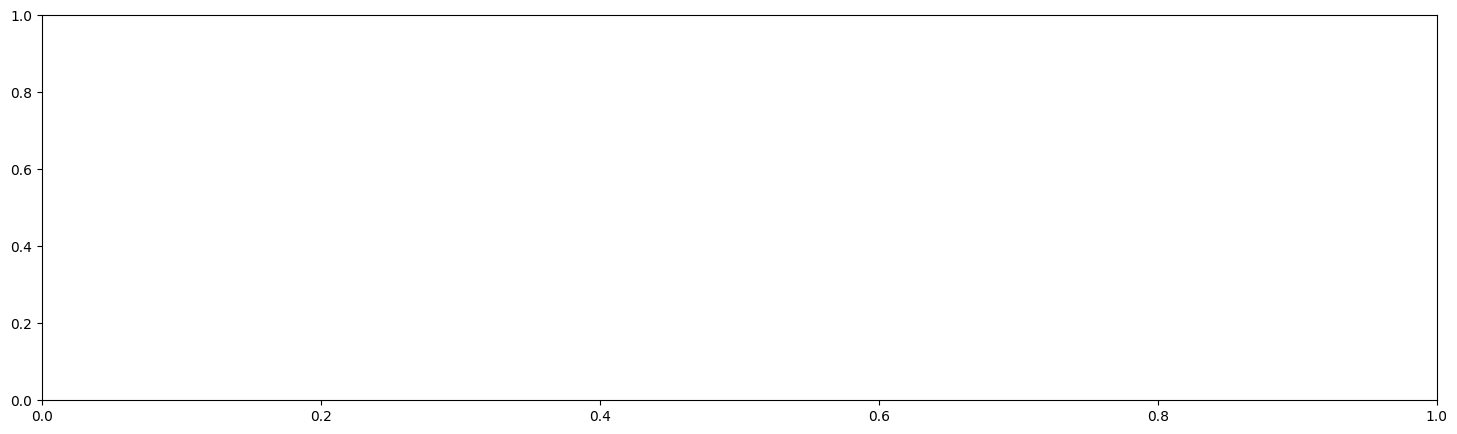

In [ ]:
# Scatter plots: true vs predicted for each approach
y_test_arr = np.asarray(y_p_test)

fig, ax = plt.subplots(1, 1, figsize=(18, 5))

for (label, ens_pred) in  [
    # ("Baseline (6q)", ens_base),
    # ("Concat A (12q)", ens_a),
    ("Sequential B (6q)", ens_b),
]:
    abs_err = np.abs(ens_pred - y_test_arr)
    sc = ax.scatter(y_test_arr, ens_pred, c=abs_err, cmap="viridis", s=30, edgecolors="black", linewidths=0.3)
    ax.plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()], "r--")
    ax.set_xlabel("True TTNS (s)")
    ax.set_ylabel("Predicted TTNS (s)")
    ax.set_title(label)
    ax.set_xscale("log")
    ax.set_yscale("log")
    plt.colorbar(sc, ax=ax, label="|Error| (s)")

plt.suptitle("True vs Predicted TTNS — Three Approaches", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Bar chart comparing all three approaches
labels = ["Baseline", "Concat (A)", "Sequential (B)"]
ensembles = [ens_base, ens_a, ens_b]

test_rmses = [root_mean_squared_error(y_p_test, e) for e in ensembles]
test_maes = [mean_absolute_error(y_p_test, e) for e in ensembles]
test_r2s = [r2_score(y_p_test, e) for e in ensembles]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ["steelblue", "coral", "seagreen"]

axes[0].bar(labels, test_rmses, color=colors, edgecolor="black")
axes[0].set_ylabel("Test RMSE (s)")
axes[0].set_title("Test RMSE")

axes[1].bar(labels, test_maes, color=colors, edgecolor="black")
axes[1].set_ylabel("Test MAE (s)")
axes[1].set_title("Test MAE")

axes[2].bar(labels, test_r2s, color=colors, edgecolor="black")
axes[2].set_ylabel("Test R2")
axes[2].set_title("Test R2")

plt.suptitle("QRC Approach Comparison — Ensemble Metrics", fontsize=14)
plt.tight_layout()
plt.show()